In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### DataSet Learing

In [179]:
df = pd.read_csv("data/german.csv", sep=";")
print(df.head(5))

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

In [180]:
print(df.shape)

(1000, 21)


In [181]:
print(df.isnull().sum())

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64


In [182]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_available_asset   

In [183]:
print(df.columns) #Creditability

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='str')


In [184]:
print(df["Creditability"].value_counts()) #1-Good 0 - Bad

Creditability
1    700
0    300
Name: count, dtype: int64


In [185]:
print(df["Creditability"].value_counts(normalize=True)*100)

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


In [186]:
df.dtypes

Creditability                        int64
Account_Balance                      int64
Duration_of_Credit_monthly           int64
Payment_Status_of_Previous_Credit    int64
Purpose                              int64
Credit_Amount                        int64
Value_Savings_Stocks                 int64
Length_of_current_employment         int64
Instalment_per_cent                  int64
Sex_Marital_Status                   int64
Guarantors                           int64
Duration_in_Current_address          int64
Most_valuable_available_asset        int64
Age_years                            int64
Concurrent_Credits                   int64
Type_of_apartment                    int64
No_of_Credits_at_this_Bank           int64
Occupation                           int64
No_of_dependents                     int64
Telephone                            int64
Foreign_Worker                       int64
dtype: object

In [187]:
categorical = df.select_dtypes(include="object").columns
numerical = df.select_dtypes(exclude="object").columns
print(categorical)
print(numerical)

Index([], dtype='str')
Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='str')


In [188]:
df.describe()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


<Axes: >

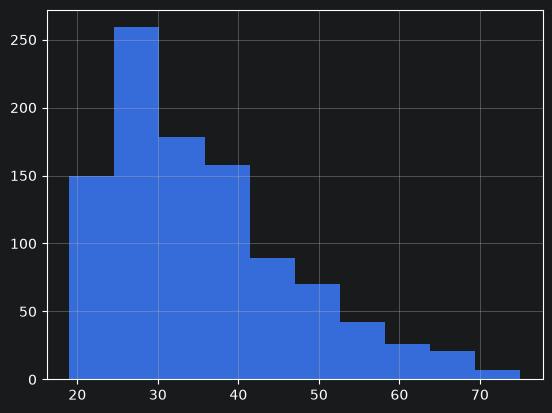

In [189]:
df["Age_years"].hist()

<Axes: >

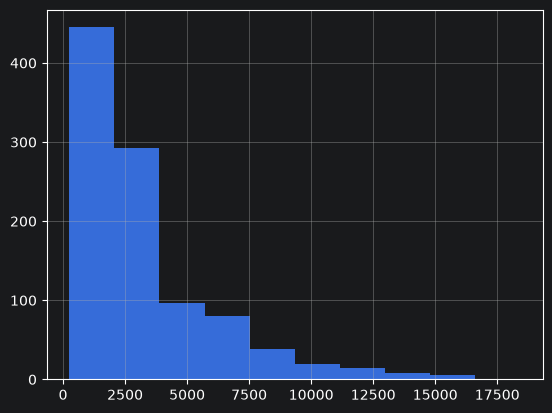

In [190]:
# print(df["Credit_Amount"])
df["Credit_Amount"].hist()

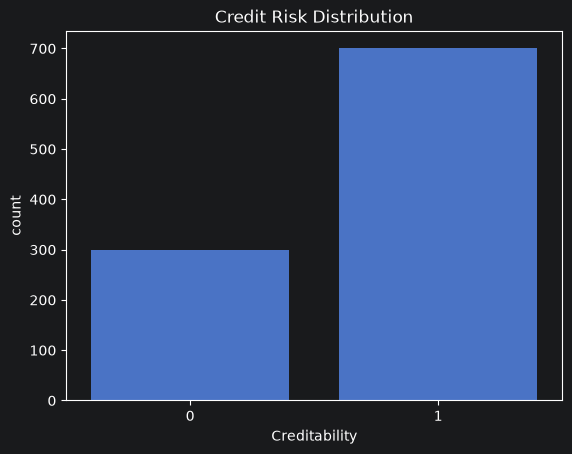

In [191]:
sns.countplot(x="Creditability", data=df)
plt.title("Credit Risk Distribution")
plt.show()

### Exploratory Data Analysis

In [192]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

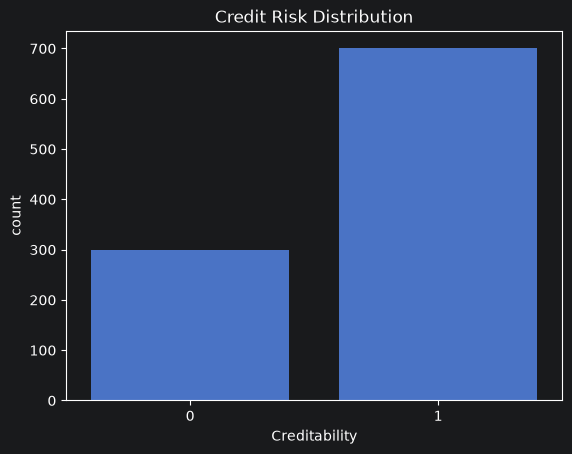

In [193]:
sns.countplot(x="Creditability", data=df)
plt.title("Credit Risk Distribution")
plt.show()

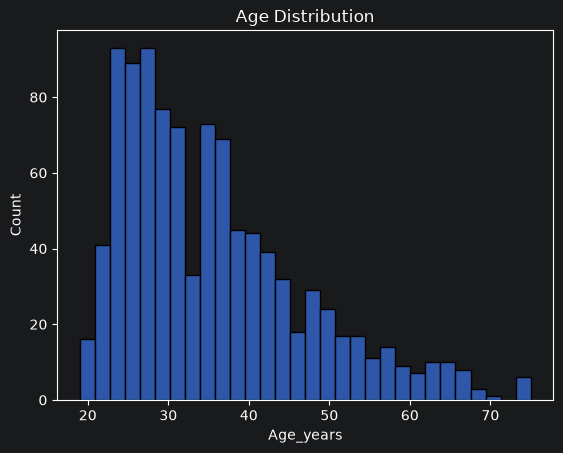

In [194]:
sns.histplot(df["Age_years"], bins=30)
plt.title("Age Distribution")
plt.show()

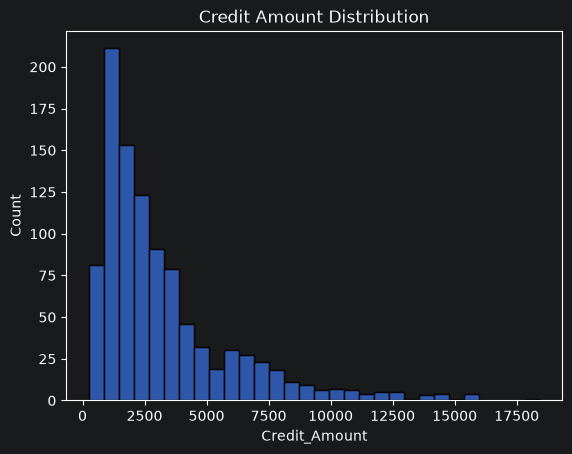

In [195]:
sns.histplot(df["Credit_Amount"], bins=30)
plt.title("Credit Amount Distribution")
plt.show()

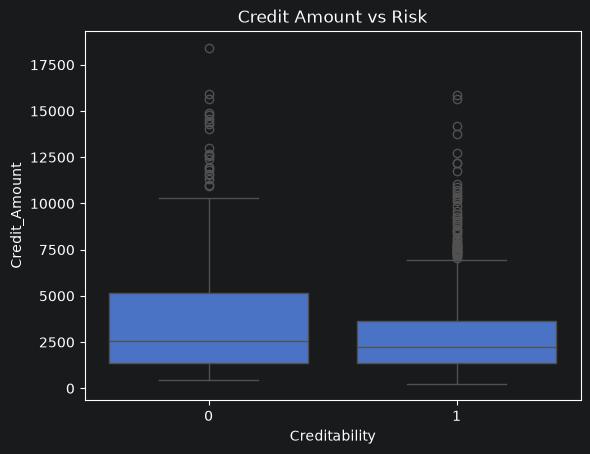

In [196]:
sns.boxplot(x="Creditability", y="Credit_Amount", data=df)
plt.title("Credit Amount vs Risk")
plt.show()

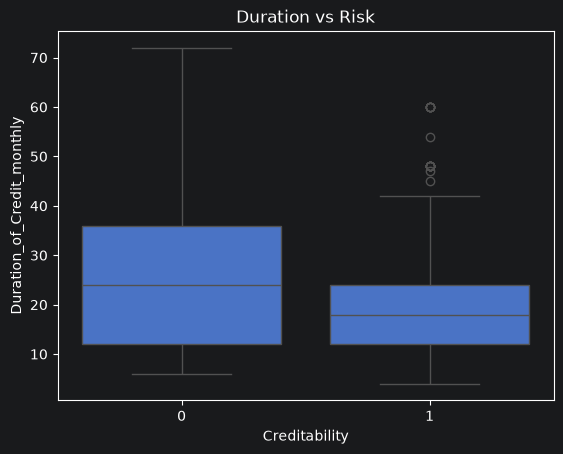

In [197]:
sns.boxplot(x="Creditability", y="Duration_of_Credit_monthly", data=df)
plt.title("Duration vs Risk")
plt.show()

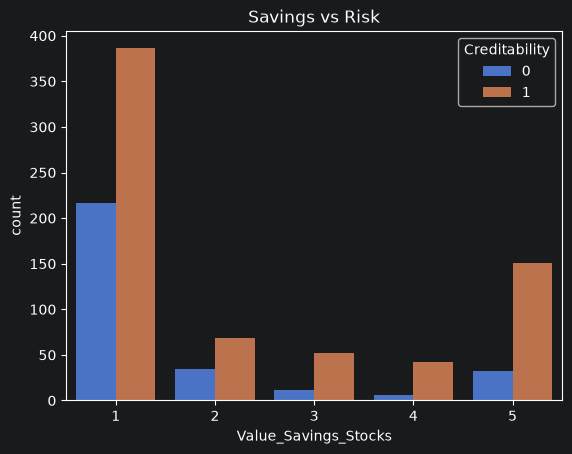

In [198]:
sns.countplot(x="Value_Savings_Stocks", hue="Creditability", data=df)
plt.title("Savings vs Risk")
plt.show()

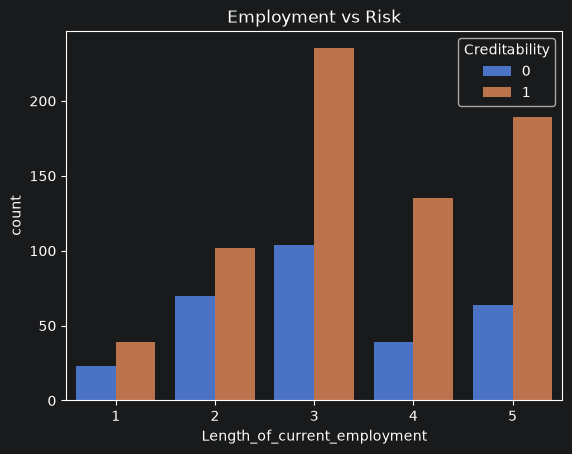

In [199]:
sns.countplot(x="Length_of_current_employment", hue="Creditability", data=df)
plt.title("Employment vs Risk")
plt.show()

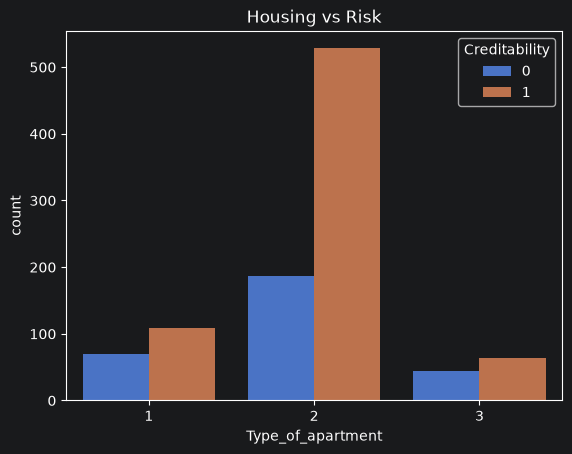

In [200]:
sns.countplot(x="Type_of_apartment", hue="Creditability", data=df)
plt.title("Housing vs Risk")
plt.show()

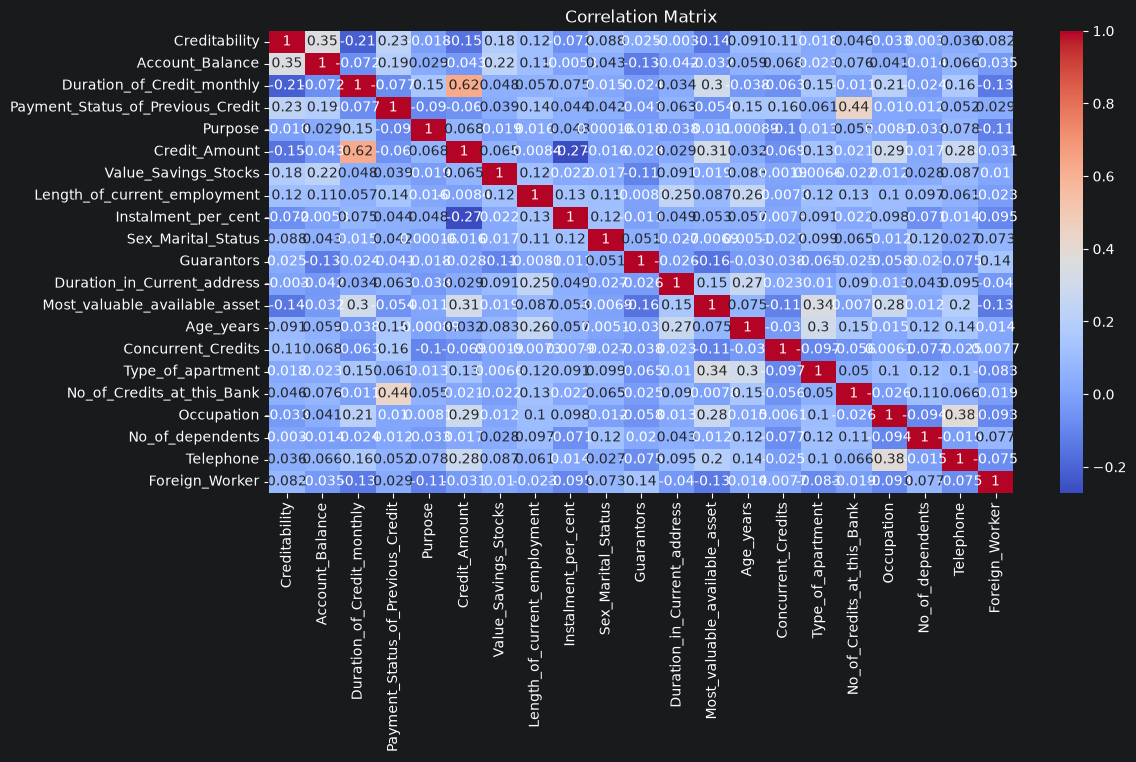

In [201]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

EDA Insights:

- Dataset has class imbalance
- Credit amount is higher for risky customers
- Longer duration increases risk
- Savings and employment strongly affect creditability
- Age has weak correlation

### Data Preprocessing

In [202]:
df.isnull().sum()

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64

In [203]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include="object").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [204]:
df[["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]] = df[["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]].astype(float)

In [205]:
X = df.drop("Creditability", axis=1)
y = df["Creditability"]

In [206]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [207]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [208]:
from imblearn.over_sampling import SMOTE
X_train_resampled, y_train_resampled = SMOTE().fit_resample(X_train, y_train)

In [209]:
X_train_resampled.head(5)

,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,4,12.0,4,9,1185.0,1,3,3,2,1,2,1,27.0,3,2,2,3,1,1,1
1,4,6.0,4,0,2080.0,3,3,1,4,1,2,3,24.0,3,2,1,3,1,1,1
2,1,6.0,4,0,1361.0,1,2,2,3,1,4,1,40.0,3,2,1,2,2,1,2
3,1,15.0,4,2,1433.0,1,3,4,2,1,3,2,25.0,3,1,2,3,1,1,1
4,1,12.0,2,2,1657.0,1,3,2,3,1,2,1,27.0,3,2,1,3,1,1,1


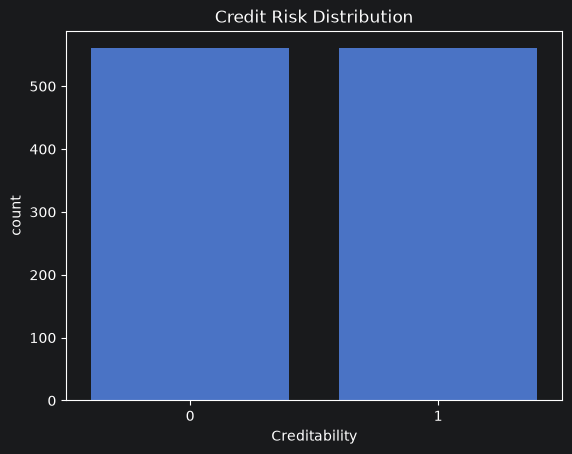

In [210]:
sns.countplot(x="Creditability", data=pd.DataFrame(y_train_resampled))
plt.title("Credit Risk Distribution")
plt.show()

In [211]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]

scaler = StandardScaler()

X_train_res_sc = X_train_resampled.copy()
X_test_sc = X_test.copy()

In [212]:
X_train_res_sc[continuous_cols] = scaler.fit_transform(X_train_resampled[continuous_cols])
X_test_sc[continuous_cols] = scaler.transform(X_test[continuous_cols])

### Model Training

In [213]:
print(df["Purpose"])
# df.describe().loc["min"].sort_values(ascending=False)

0      2
1      0
2      9
3      0
4      0
      ..
995    3
996    0
997    0
998    3
999    2
Name: Purpose, Length: 1000, dtype: int64


#### Logistic Regression

In [214]:
from sklearn.linear_model import LogisticRegression

logReg = LogisticRegression(class_weight="balanced", max_iter=1000)
logReg.fit(X_train_res_sc, y_train_resampled)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [215]:
preds = logReg.predict(X_test_sc)
y_pred_prob = logReg.predict_proba(X_test_sc)[:, 1]
gr_truth = np.array(y_test)
result = preds[preds == gr_truth]
print(len(result))
print(len(result[result == 0]))
print(result)

149
39
[1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0
 0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0
 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0
 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1
 1]


In [216]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report
)


print("\n─── Metrics ───────────────────────────────────────")
print(f"Accuracy  : {accuracy_score(y_test, preds):.3f}")
print(f"Precision : {precision_score(y_test, preds):.3f}")
print(f"Recall    : {recall_score(y_test, preds):.3f}")
print(f"F1 Score  : {f1_score(y_test, preds):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.3f}")

print("\n─── Classification Report ──────────────────────────")
print(classification_report(y_test, preds, target_names=["Bad risk", "Good risk"]))


─── Metrics ───────────────────────────────────────
Accuracy  : 0.745
Precision : 0.840
Recall    : 0.786
F1 Score  : 0.812
ROC-AUC   : 0.794

─── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Bad risk       0.57      0.65      0.60        60
   Good risk       0.84      0.79      0.81       140

    accuracy                           0.74       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.76      0.74      0.75       200



In [217]:
# instead of default 0.5, use 0.65
y_pred_custom = (y_pred_prob >= 0.65).astype(int)

print(accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom, target_names=["Bad risk", "Good risk"]))

0.705
              precision    recall  f1-score   support

    Bad risk       0.51      0.78      0.61        60
   Good risk       0.88      0.67      0.76       140

    accuracy                           0.70       200
   macro avg       0.69      0.73      0.69       200
weighted avg       0.77      0.70      0.72       200



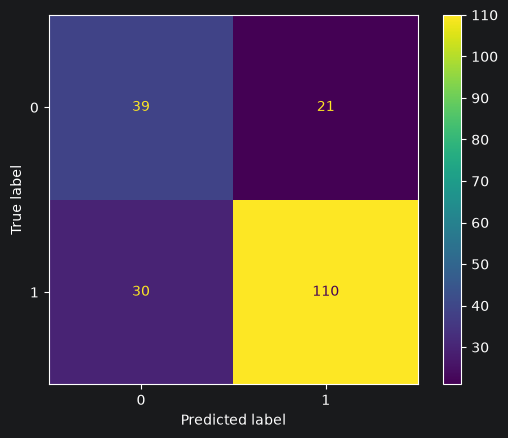

In [218]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,preds)

plt.show()

#### Random Forest

In [219]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train_res_sc, y_train_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [220]:
y_pred = rf.predict(X_test_sc)
y_pred_prob = rf.predict_proba(X_test_sc)[:, 1]

In [221]:
print("\n─── Random Forest Metrics ─────────────────────────")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.3f}")

print("\n─── Classification Report ──────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Bad risk", "Good risk"]))


─── Random Forest Metrics ─────────────────────────
Accuracy  : 0.765
Precision : 0.835
Recall    : 0.829
F1 Score  : 0.832
ROC-AUC   : 0.830

─── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Bad risk       0.61      0.62      0.61        60
   Good risk       0.83      0.83      0.83       140

    accuracy                           0.77       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.77      0.77      0.77       200



In [222]:
import joblib

joblib.dump(logReg, "credit_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [223]:
print(df.columns)
print(df.dtypes)
print(encoders.keys())

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='str')
Creditability                          int64
Account_Balance                        int64
Duration_of_Credit_monthly           float64
Payment_Status_of_Previous_Credit      int64
Purpose                                int64
Credit_Amount                        float64
Value_Savings_Stocks                   int64
Length_of_current_employment           int64
Instalment_per_cent                    int64
Sex_Marital_Status                     int64
Guarantors   